En esta libreta exploramos el proceso de descarga de un conjunto de datos en formato shapefile con información sobre los municipios de México. 

# Datos geograficos

Definimos el url de acceso a los datos: 

In [1]:
url_geo_data = r'http://www.conabio.gob.mx/informacion/gis/maps/geo/mun22gw.zip'

In [2]:
import requests

In [3]:
r = requests.get(url_geo_data, stream=True)
r.raise_for_status()

In [4]:
for k, v in r.headers.items(): print(k, v)

Date Tue, 21 Apr 2026 18:15:35 GMT
Server Apache/2.2.11 (Unix) mod_python/3.3.1 Python/2.5.1 mod_ssl/2.2.11 OpenSSL/0.9.8f PHP/5.2.6 mod_perl/2.0.4 Perl/v5.8.7
Last-Modified Mon, 18 Sep 2023 19:06:37 GMT
ETag "c0b326-2b80e70-605a6d769a940"
Accept-Ranges bytes
Content-Length 45616752
Keep-Alive timeout=15, max=100
Connection Keep-Alive
Content-Type application/zip


In [5]:
r.close()

In [6]:
from incidencia_delictiva.config import DATA_DIR

In [7]:
temp_dir = DATA_DIR / "temp"
temp_dir.mkdir(exist_ok=True)

output_file = temp_dir / 'geograficos_mun.zip'

In [9]:
from tqdm.auto import tqdm

In [10]:
with requests.get(url_geo_data, stream=True) as r:
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))

    with open(output_file, 'wb') as f, tqdm(
        total=total, unit='B', unit_scale=True, desc=output_file.name, leave=False
    ) as pbar:
        for chunk in r.iter_content(1024):
            f.write(chunk)
            pbar.update(len(chunk))

Extraemos el zipfile: 

In [11]:
import zipfile

In [12]:
zf = zipfile.ZipFile(output_file, 'r')

Los elementos:

In [13]:
zf.namelist()

['mun22gw.dbf',
 'mun22gw.html',
 'mun22gw.png',
 'mun22gw.prj',
 'mun22gw.shp',
 'mun22gw.shx',
 'mun22gw.xml',
 'mun22gw_s.png',
 'README_zip.txt']

Extraemos los elementos comprimidos: 

In [14]:
geodata_dir = temp_dir / "geo_data"; geodata_dir.mkdir(exist_ok=True); 

zf.extractall(path=geodata_dir)
zf.close()

Verificamos los archivos extraidos: 

In [15]:
for item in geodata_dir.iterdir(): print(item.relative_to(DATA_DIR))

temp/geo_data/mun22gw.prj
temp/geo_data/mun22gw_s.png
temp/geo_data/README_zip.txt
temp/geo_data/mun22gw.png
temp/geo_data/mun22gw.xml
temp/geo_data/mun22gw.shx
temp/geo_data/mun22gw.shp
temp/geo_data/mun22gw.html
temp/geo_data/mun22gw.dbf


Cargamos el archivo en geopandas: 

In [16]:
import geopandas as gpd

In [17]:
shapefile_path = geodata_dir / "mun22gw.shp"

gdf = gpd.read_file(shapefile_path)
gdf.head()

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,NOM_ENT,COV_,COV_ID,AREA,PERIMETER,geometry
0,01008,01,008,San JosÃ© de Gracia,Aguascalientes,0,1,85779.057424,181537.599566,"POLYGON ((-102.35385 22.12064, -102.35426 22.1..."
1,01009,01,009,TepezalÃ¡,Aguascalientes,1,2,22966.101228,89329.531705,"POLYGON ((-102.16213 22.34851, -102.16149 22.3..."
2,01010,01,010,El Llano,Aguascalientes,2,3,50405.098875,144866.490025,"POLYGON ((-101.89778 21.95839, -101.89037 21.9..."
3,01011,01,011,San Francisco de los Romo,Aguascalientes,3,4,13777.017628,103689.065527,"POLYGON ((-102.14088 22.07534, -102.14086 22.0..."
4,01001,01,001,Aguascalientes,Aguascalientes,4,5,116635.924756,256631.025245,"POLYGON ((-102.09775 22.02325, -102.09857 22.0..."


- La columna `CVEGEO` permitirá hacer el join de con los demás datasets.
- La columna `AREA` permitirá obtener la feature `densidad_poblacional` que la definiremos como la población por $\text{Km}^2$

In [50]:
gdf.columns.str.lower()

Index(['cvegeo', 'cve_ent', 'cve_mun', 'nomgeo', 'nom_ent', 'cov_', 'cov_id',
       'area', 'perimeter', 'geometry', 'area_km2', 'region', 'es_frontera',
       'zona_metropolitana', 'zona_metropolitana_nombre', 'centroid'],
      dtype='str')

In [18]:
import matplotlib.pyplot as plt

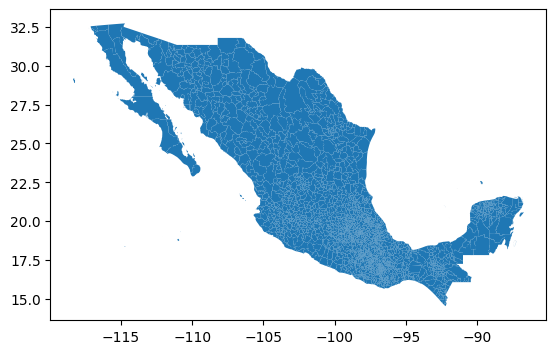

In [19]:
gdf.plot()
plt.show()

Verifiquemos que el área definida en el dataset es correcta.

Las coordenadas geográficas se encuentran en lat,long. Reproyectamos a un CRS métrico: 

In [20]:
gdf = gdf.to_crs(epsg=6372)

In [21]:
gdf["area_km2"] = gdf.geometry.area / 1e6

Verificamos el resultado con el municipio de Hermosillo: 

In [22]:
gdf.query("CVEGEO == '26030'")

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,NOM_ENT,COV_,COV_ID,AREA,PERIMETER,geometry,area_km2
1952,26030,26,030,Hermosillo,Sonora,1952,1948,1.690800e+06,1.157340e+06,"MULTIPOLYGON (((1471420.765 1889158.632, 14714...",16908.004997


La cantidad obtenida es razonable según el artículo de [Wikipedia](https://es.wikipedia.org/wiki/Municipio_de_Hermosillo).

La cantidad de municipios registrados: 

In [23]:
len(gdf['CVEGEO'].unique())

2475

Las entidades federativas:

In [24]:
gdf['NOM_ENT'].unique()

<StringArray>
[                 'Aguascalientes',                 'Baja California',
             'Baja California Sur',                        'Campeche',
            'Coahuila de Zaragoza',                          'Colima',
                         'Chiapas',                       'Chihuahua',
               'Ciudad de MÃ©xico',                         'Durango',
                      'Guanajuato',                        'Guerrero',
                         'Hidalgo',                         'Jalisco',
                         'MÃ©xico',            'MichoacÃ¡n de Ocampo',
                         'Morelos',                         'Nayarit',
                     'Nuevo LeÃ³n',                          'Oaxaca',
                          'Puebla',                      'QuerÃ©taro',
                    'Quintana Roo',                'San Luis PotosÃ­',
                         'Sinaloa',                          'Sonora',
                         'Tabasco',                      'Tamau

Observamos que hay erres de encoding. 

Agrupamos por `NOM_ENT` y `CVE_ENT`: 

In [25]:
gdf.groupby('NOM_ENT')['CVE_ENT'].first()

NOM_ENT
Aguascalientes                     01
Baja California                    02
Baja California Sur                03
Campeche                           04
Chiapas                            07
Chihuahua                          08
Ciudad de MÃ©xico                  09
Coahuila de Zaragoza               05
Colima                             06
Durango                            10
Guanajuato                         11
Guerrero                           12
Hidalgo                            13
Jalisco                            14
MichoacÃ¡n de Ocampo               16
Morelos                            17
MÃ©xico                            15
Nayarit                            18
Nuevo LeÃ³n                        19
Oaxaca                             20
Puebla                             21
QuerÃ©taro                         22
Quintana Roo                       23
San Luis PotosÃ­                   24
Sinaloa                            25
Sonora                             26
Taba

Con lo anterior, podemos mapear desde la clave del municipio a la región en la que se encuentra. 

Definimos el diccionario para mapear los municipios: 

In [26]:
region_map = {
    # Noroeste
    '02': 'noroeste', '03': 'noroeste',
    '25': 'noroeste', '26': 'noroeste',

    # Norte
    '05': 'norte', '08': 'norte',

    # Noreste
    '19': 'noreste', '28': 'noreste',

    # Occidente
    '14': 'occidente', '16': 'occidente',
    '18': 'occidente', '32': 'occidente',
    '06': 'occidente',

    # Centro-Norte
    '01': 'centro-norte', '10': 'centro-norte',
    '24': 'centro-norte',

    # Centro-Sur
    '09': 'centro-sur', '11': 'centro-sur',
    '13': 'centro-sur', '15': 'centro-sur',
    '17': 'centro-sur', '21': 'centro-sur',
    '22': 'centro-sur', '29': 'centro-sur',

    # Sur
    '07': 'sur', '12': 'sur', '20': 'sur',

    # Sureste
    '04': 'sureste', '23': 'sureste',
    '27': 'sureste', '30': 'sureste',
    '31': 'sureste'
}

La divición geográfica ha sido seleccionada en base al artículo [Regiones de México](https://es.wikipedia.org/wiki/Regiones_de_M%C3%A9xico) de Wikipedia. 

Definimos la columna `region`: 

In [27]:
gdf['CVE_ENT'] = gdf['CVE_ENT'].astype(str).str.zfill(2)

In [28]:
gdf['CVE_ENT'].unique()

<StringArray>
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13',
 '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26',
 '27', '28', '29', '30', '31', '32']
Length: 32, dtype: str

In [29]:
tmp = gdf['CVE_ENT'].map(region_map)

In [30]:
gdf[tmp.isna()]

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,NOM_ENT,COV_,COV_ID,AREA,PERIMETER,geometry,area_km2


In [31]:
gdf['region'] = gdf['CVE_ENT'].map(region_map)

In [32]:
gdf['region'].value_counts().sum()

np.int64(2475)

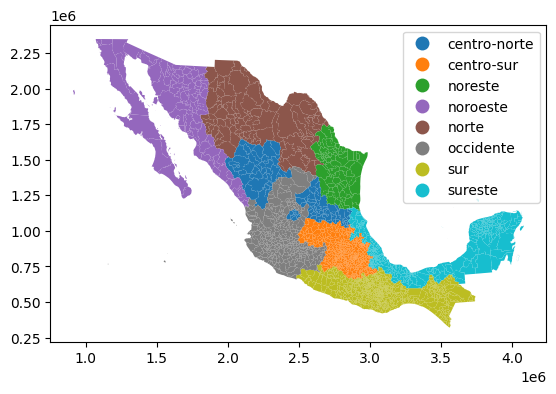

In [33]:
gdf.plot(column='region', legend=True); 

comentarios...

Otra columna que podemos integrar es un indicador de si el municipio se encuentra en frontera. 

In [34]:
frontera_norte = [
    '02', '26', '08',
    '05', '19', '28'
]

frontera_sur = [
    '07', '27', '04', '23'
]

gdf['es_frontera'] = gdf['CVE_ENT'].isin(frontera_norte + frontera_sur).astype(int)

In [51]:
gdf['es_frontera'].value_counts()

es_frontera
0    2032
1     443
Name: count, dtype: int64

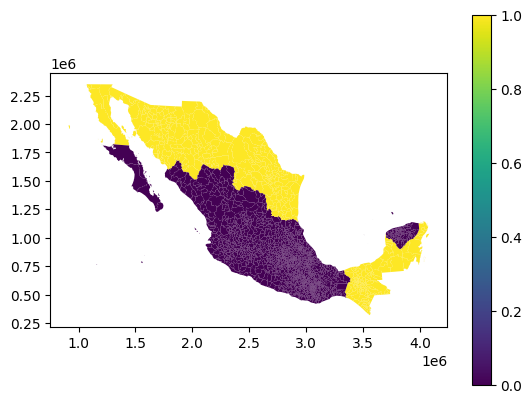

In [35]:
gdf.plot(column='es_frontera', legend=True); 

comentarios...

Según la [CONAPO](http://www.conapo.gob.mx/work/models/CONAPO/zonas_metropolitanas2000/completo.pdf) en méxico existen 55 zonas metropolitanas. Podemos usar esta información para complementar el dataset: 

In [36]:
gdf.query(
    (
        "CVEGEO == '05010'"
    )
)

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,NOM_ENT,COV_,COV_ID,AREA,PERIMETER,geometry,area_km2,region,es_frontera
56,05010,05,010,Frontera,Coahuila de Zaragoza,56,57,45409.124879,119164.598064,"POLYGON ((2564368.061 1667402.016, 2564213.395...",454.091249,norte,1


In [37]:
zm_map = {
    'aguas_calientes': ['01001', '01005'], 
    'tijuana': ['01001', '02005'], 
    'monclova': ['05006', '05010', '05018'], 
    'piedras_negras': ['05025', '05022'], 
    'saltillo': ['05004', '05027', '05030'], 
    'la_laguna': ['05017', '05035', '10007', '10012'], 
    'colima_villa_alvarez': ['06002', '06010'], 
    'tecoman': ['06001', '06009'],
    'tuxtla': ['07027', '07101'],
    'chuhuahua': ['08002', '08004', '08019'], 
    'juarez': ['08037'], 
    
    'valle_de_mexico': [
        '15038', '15039', '15044', '15046', '15050', '15053', '15057', '15058',
        '15059', '15060', '15065', '15068', '15069', '15070', '15075', '15081',
        '15083', '15084', '15089', '15091', '15092', '15093', '15094', '15095', 
        '15096', '15099', '15100', '15103', '15104', '15108', '15109', '15112',
        '15120', '15121', '15122'
    ], 
    'moroleon': ['11021', '11041'], 
    'leon': ['11020', '11037'], 
    'san_fco_rincon': ['11025', '11031'], 
    'acapulco': ['12001', '12021'], 
    'pachuca': ['13022', '13039', '13048', '13051', '13052', '13082', '13083'], 
    'tulancingo': ['13016', '13056', '13077'], 
    'tula': ['13010', '13013', '13070', '13074', '13076'], 
    'guadalajara': ['14039', '14044', '14051', '14070', '14097', '14098', '14101', '14120'], 
    'ocotlan': ['14063', '14066'], 
    'puerto_vallarta': ['14067', '18020'], 
    'toluca': ['15005', '15018', '15027', '15051', '15054', '15055', '15062', '15067', '15076', '15106', '15115', '15118'], 
    'zamora': ['16043', '16108'], 
    'la_piedad': ['11023', '16069'], 
    'morelia': ['16053', '16068'], 
    'cuautla': ['17002', '17004', '17006', '17029', '17030'], 
    'cuerna_vaca': ['17007', '17008', '17011', '17018', '17020', '17028'], 
    'tepic': ['18008', '18017'], 
    'monterrey': ['19006', '19018', '19019', '19021', '19026', '19031', '19039', '19045', '19046', '19048', '19049'], 
    'oaxaca': ['20083', '20087', '20091', '20107', '20115', '20157', '20174', '20293', '20350', '20375', '20385', '20390', '20399', '20403', '20409', '20519', '20553'], 
    'puebla': ['21015', '21034', '21041', '21090', '21106', '21114', '21119', '21125', '21136', '21140', '29017', '29022', '29025', '29027', '29028', '29029', '29041', '29042', '29044', '29053', '29054', '29058', '29059'], 
    'texmelucan': ['21132', '21143'], 
    'queretaro': ['22006', '22011', '22014'], 
    'cancun': ['23003', '23005'], 
    'rioverde': ['24011', '24024'], 
    'san_luis_potosi': ['24028', '24035'], 
    'guaymas': ['26025', '26029'],
    'villahermosa': ['27004', '27013'], 
    'tampico': ['28003', '28009', '28038', '30123', '30133'], 
    'matamoros': ['28022'], 
    'nuevo_laredo': ['28027'], 
    'reynosa': ['28032', '28033'], 
    'apizco': ['29005', '29009', '29026', '29031', '29035', '29038', '29039', '29043'], 
    'tlaxcala': ['29001', '29002', '29010', '29018', '29024', '29033', '29036', '29048', '29049', '29050', '29060'], 
    'acayucan': ['30003', '30116', '30145'], 
    'coatzacoalcos': ['30039', '30082', '30206'], 
    'minititlan': ['30048', '30059', '30089', '30108', '30120', '30199'], 
    'cordoba': ['30014', '30044', '30068', '30196'], 
    'xalapa': ['30026', '30038', '30087', '30093', '30136', '30182'], 
    'orizaba': ['30022', '30030', '30074', '30081', '30085', '30101', '30115', '30118', '30135', '30138', '30185'], 
    'poza_rica': ['30040', '30124', '30131', '30175'], 
    'veracruz': ['30011', '30028', '30193'], 
    'merida': ['31013', '31041', '31050', '31100', '31101'], 
    'zacatecas': ['32017', '32056']
}

Verificamos la cantidad de zonas metropolitanas: 

In [38]:
len(zm_map)

55

In [39]:
zm_mpios = set(
    mun for lst in zm_map.values() for mun in lst
)

In [40]:
len(zm_mpios)

267

Creamos la dummy column para zona metropolitana: 

In [41]:
gdf['zona_metropolitana'] = gdf['CVEGEO'].isin(zm_mpios).astype(int)

In [42]:
gdf["zona_metropolitana"].value_counts()

zona_metropolitana
0    2208
1     267
Name: count, dtype: int64

Verificamos resultados: 

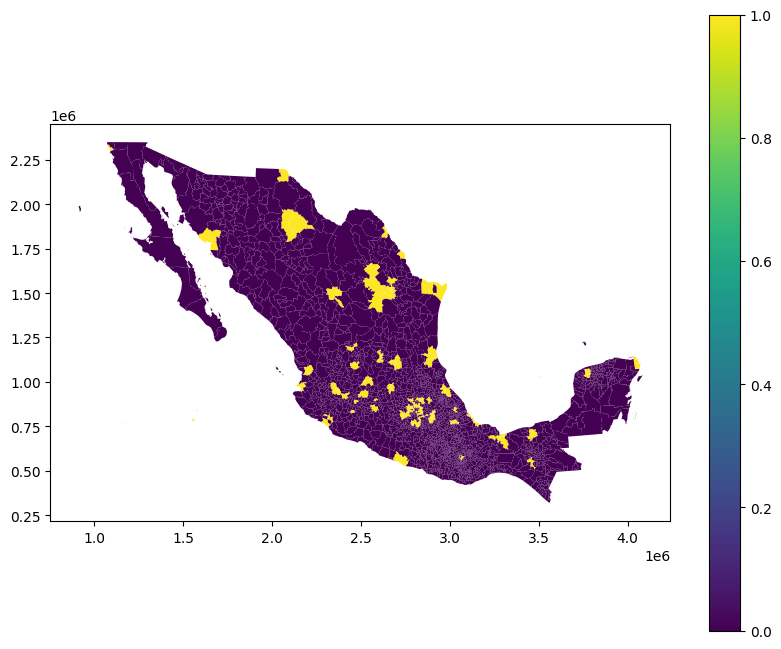

In [43]:
gdf.plot(column="zona_metropolitana", figsize=(10,8), legend=True); 

In [44]:
zm_lookup = {
    mun: zm for zm, lista in zm_map.items() for mun in lista
}

gdf['zona_metropolitana_nombre'] = gdf['CVEGEO'].map(zm_lookup)

In [52]:
gdf['zona_metropolitana_nombre'] .value_counts()

zona_metropolitana_nombre
valle_de_mexico         35
puebla                  23
oaxaca                  17
toluca                  12
monterrey               11
tlaxcala                11
orizaba                 11
guadalajara              8
apizco                   8
pachuca                  7
cuerna_vaca              6
xalapa                   6
minititlan               6
tula                     5
cuautla                  5
tampico                  5
merida                   5
la_laguna                4
cordoba                  4
poza_rica                4
saltillo                 3
monclova                 3
chuhuahua                3
tulancingo               3
queretaro                3
acayucan                 3
veracruz                 3
coatzacoalcos            3
tijuana                  2
piedras_negras           2
colima_villa_alvarez     2
tecoman                  2
tuxtla                   2
san_fco_rincon           2
leon                     2
moroleon                 2
la

Computamos los centroides: 

In [45]:
gdf['centroid'] = gdf.geometry.centroid

In [46]:
gdf.head()

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,NOM_ENT,COV_,COV_ID,AREA,PERIMETER,geometry,area_km2,region,es_frontera,zona_metropolitana,zona_metropolitana_nombre,centroid
0,01008,01,008,San JosÃ© de Gracia,Aguascalientes,0,1,85779.057424,181537.599566,"POLYGON ((2463679.819 1122454.043, 2463636.551...",857.790574,centro-norte,0,0,NaN,POINT (2446037.488 1125367.26)
1,01009,01,009,TepezalÃ¡,Aguascalientes,1,2,22966.101228,89329.531705,"POLYGON ((2483386.269 1147520.506, 2483452.328...",229.661012,centro-norte,0,0,NaN,POINT (2480295.94 1135235.65)
2,01010,01,010,El Llano,Aguascalientes,2,3,50405.098875,144866.490025,"POLYGON ((2510504.977 1104537.995, 2511266.668...",504.050989,centro-norte,0,0,NaN,POINT (2496358.496 1100471.978)
3,01011,01,011,San Francisco de los Romo,Aguascalientes,3,4,13777.017628,103689.065527,"POLYGON ((2485534.556 1117425.794, 2485536.613...",137.770176,centro-norte,0,0,NaN,POINT (2476476.217 1112780.038)
4,01001,01,001,Aguascalientes,Aguascalientes,4,5,116635.924756,256631.025245,"POLYGON ((2489959.178 1111683.059, 2489874.765...",1166.359248,centro-norte,0,1,tijuana,POINT (2469560.28 1088371.808)


Con lo anterior, podemos definir una nueva variable: la distancia de cada municipio a la zona metropolitana más cercana. 